### Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import os
import cv2
import matplotlib.pyplot as plt
from tensorflow import keras
import seaborn as sns
from keras import Sequential,layers
from tensorflow.keras.layers import Flatten,Dense,InputLayer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score
import tensorflow as tf

### Loading Dataset

In [2]:
folder_path=r"C:\Users\desai\Downloads\archive\trainingSet\trainingSet"

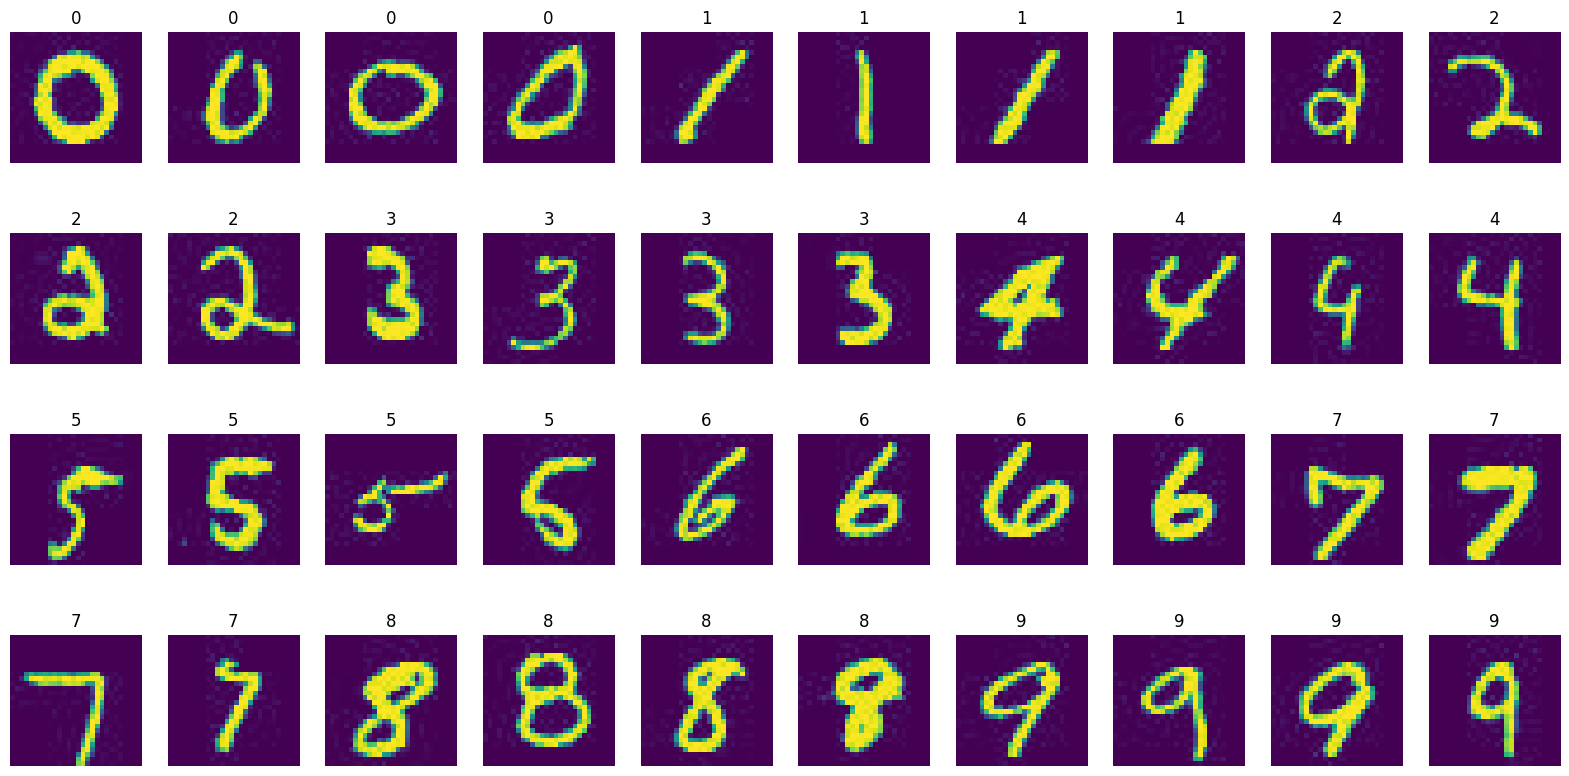

In [3]:
plt.figure(figsize=(20,10))
img_to_show=4
for class_index,class_name in enumerate(os.listdir(folder_path)):
    for img_index,img_name in enumerate(os.listdir(os.path.join(folder_path,class_name))[:img_to_show],1):
        img_path=os.path.join(folder_path,class_name,img_name)
        img_arr=cv2.imread(img_path,cv2.IMREAD_GRAYSCALE)
        plt.subplot(4,10,(class_index*img_to_show)+img_index)
        plt.imshow(img_arr)
        plt.title(class_name)
        plt.axis("off")
        #print(img_path)
        #print(img_index)
    #print(class_index)
plt.show()
    

In [4]:
img_arr.shape

(28, 28)

In [5]:
img_arr

array([[  0,   0,   0,   0,   0,   0,   0,   0,   3,   0,   4,   3,   0,
          0,   8,   0,   3,   1,   8,   0,  13,   0,   0,   4,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,  12,   5,   0,  12,
          0,   0,   8,   0,   6,   0,   0,   7,   6,  11,   2,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,  18,   0,   0,   0,   0,
          6,   7,   0,   0,   0,   0,  18,   3,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  10,  19,   0,
          0,   7,   0,  18,   0,   0,   0,   0,   5,  22,   7,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,  11,   0,   0,   7,
          3,   0,  11,   0,   0,  33,   0,   0,   0,   5,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   7,   0,   0,   0,
          2,   0,   0,   8,   0,   5,   4,  11,   0,   1,  15,   0,   0,
          0,   0],
       [  

### Collecting Data

In [6]:
labels=[]
data=[]
for class_name in os.listdir(folder_path):
    for img_name in os.listdir(os.path.join(folder_path,class_name)):
        label=int(class_name)
        labels.append(label)
        img_path=os.path.join(folder_path,class_name,img_name)
        img_arr=cv2.imread(img_path,cv2.IMREAD_GRAYSCALE)
        data.append(img_arr.flatten())

In [7]:
len(data)

42000

In [8]:
img_df=pd.DataFrame(data)
img_df

,0,1,2,3,4,5,6,7,8,9,...,774,775,776,777,778,779,780,781,782,783
0,3,0,0,3,7,3,0,3,0,11,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,8,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,2,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,9,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,2,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41995,0,0,0,0,0,0,0,0,1,1,...,0,0,0,0,0,0,0,0,0,0
41996,0,0,0,0,0,0,0,0,0,4,...,0,0,0,0,0,0,0,0,0,0
41997,0,3,6,1,0,2,2,0,0,7,...,4,7,0,0,1,0,0,0,0,0
41998,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [9]:
img_df['label']=labels
img_df

,0,1,2,3,4,5,6,7,8,9,...,775,776,777,778,779,780,781,782,783,label
0,3,0,0,3,7,3,0,3,0,11,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,8,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,2,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,9,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,2,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41995,0,0,0,0,0,0,0,0,1,1,...,0,0,0,0,0,0,0,0,0,9
41996,0,0,0,0,0,0,0,0,0,4,...,0,0,0,0,0,0,0,0,0,9
41997,0,3,6,1,0,2,2,0,0,7,...,7,0,0,1,0,0,0,0,0,9
41998,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,9


In [10]:
x=img_df.drop('label',axis=1).astype("float32")/255.0
y=img_df['label']
y.unique()

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

### Splitting the Data into Training and Testing

In [11]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42,stratify=labels)

In [12]:
train_ds=tf.data.Dataset.from_tensor_slices((x_train,y_train)).batch(batch_size=32).shuffle(50).prefetch(tf.data.AUTOTUNE)
val_ds=tf.data.Dataset.from_tensor_slices((x_test,y_test)).batch(batch_size=32).shuffle(50).prefetch(tf.data.AUTOTUNE)

### CNN Model

In [13]:
cnn_model=keras.Sequential([
    keras.layers.Reshape((28,28,1),input_shape=(784,)),
    keras.layers.Conv2D(32,(3,3),activation="relu"),
    keras.layers.MaxPooling2D((2,2)),
    keras.layers.Conv2D(64,(3,3),activation="relu"),
    keras.layers.MaxPooling2D((2,2)),
    keras.layers.Flatten(),
    keras.layers.Dense(64,activation="relu"),
    keras.layers.Dense(10,activation="softmax")
])

C:\Users\desai\anaconda3\envs\deep_learning2\lib\site-packages\keras\src\layers\reshaping\reshape.py:39: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [14]:
cnn_model.compile(optimizer="adam",loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [15]:
cnn_model.fit(train_ds,validation_data=val_ds,epochs=5,batch_size=32)

Epoch 1/5
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 23s 19ms/step - accuracy: 0.8580 - loss: 0.4647 - val_accuracy: 0.9711 - val_loss: 0.0907
Epoch 2/5
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 21s 20ms/step - accuracy: 0.9798 - loss: 0.0675 - val_accuracy: 0.9807 - val_loss: 0.0659
Epoch 3/5
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 20s 19ms/step - accuracy: 0.9864 - loss: 0.0445 - val_accuracy: 0.9829 - val_loss: 0.0538
Epoch 4/5
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 20s 19ms/step - accuracy: 0.9895 - loss: 0.0323 - val_accuracy: 0.9854 - val_loss: 0.0509
Epoch 5/5
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 20s 19ms/step - accuracy: 0.9920 - loss: 0.0243 - val_accuracy: 0.9864 - val_loss: 0.0556


### Saving the model weigths for deployment

In [17]:
cnn_model.save("mnist_model.h5")